In [1]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
ticker = yf.Ticker("SPY")
expirations = ticker.options
print("Available expirations:", expirations)

Available expirations: ('2026-04-09', '2026-04-10', '2026-04-13', '2026-04-14', '2026-04-15', '2026-04-16', '2026-04-17', '2026-04-20', '2026-04-24', '2026-04-30', '2026-05-01', '2026-05-08', '2026-05-15', '2026-05-22', '2026-05-29', '2026-06-18', '2026-06-30', '2026-07-17', '2026-07-31', '2026-08-21', '2026-08-31', '2026-09-18', '2026-09-30', '2026-12-18', '2026-12-31', '2027-01-15', '2027-03-19', '2027-03-31', '2027-06-17', '2027-09-17', '2027-12-17', '2028-01-21', '2028-06-16', '2028-12-15')


In [3]:
exp = expirations[2]
chain = ticker.option_chain(exp)

In [4]:
calls = chain.calls
puts = chain.puts

In [5]:
print(calls.columns.tolist())

['contractSymbol', 'lastTradeDate', 'strike', 'lastPrice', 'bid', 'ask', 'change', 'percentChange', 'volume', 'openInterest', 'impliedVolatility', 'inTheMoney', 'contractSize', 'currency']


In [6]:
# historical price data for realized vol
spy = yf.download("SPY", start="2020-01-01", end="2025-12-31")

# implied volatility index
vix = yf.download("^VIX", start="2020-01-01", end="2025-12-31")


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [7]:
spy.head()

Price,Close,High,Low,Open,Volume
Ticker,SPY,SPY,SPY,SPY,SPY
Date,,,,,
2020-01-02,296.888184,296.906479,294.749737,295.672752,59151200
2020-01-03,294.640076,295.764143,293.442911,293.497741,77709700
2020-01-06,295.764160,295.846405,292.766647,292.885455,55653900
2020-01-07,294.932526,295.672756,294.484712,295.197527,40496400
2020-01-08,296.504425,297.719857,294.877741,295.124476,68296000


In [8]:
vix.head()

Price,Close,High,Low,Open,Volume
Ticker,^VIX,^VIX,^VIX,^VIX,^VIX
Date,,,,,
2020-01-02,12.47,13.720000,12.42,13.46,0
2020-01-03,14.02,16.200001,13.13,15.01,0
2020-01-06,13.85,16.389999,13.54,15.45,0
2020-01-07,13.79,14.460000,13.39,13.84,0
2020-01-08,13.45,15.240000,12.83,15.16,0


In [9]:
vix2 = vix[vix.index >= "2020-01-01"]
vix2.head()

Price,Close,High,Low,Open,Volume
Ticker,^VIX,^VIX,^VIX,^VIX,^VIX
Date,,,,,
2020-01-02,12.47,13.720000,12.42,13.46,0
2020-01-03,14.02,16.200001,13.13,15.01,0
2020-01-06,13.85,16.389999,13.54,15.45,0
2020-01-07,13.79,14.460000,13.39,13.84,0
2020-01-08,13.45,15.240000,12.83,15.16,0


In [10]:
#building features from raw pricing data

def vol_features(rv_df, iv_df):
    # Calculate historical volatility (realized volatility)
    df = rv_df[["Close"]].copy()
    df["log_return"] = np.log(df["Close"] / df["Close"].shift(1))
    
    #realized volatility as rolling std of log returns
    df["realized_vol5"] = df["log_return"].rolling(window=5).std() * np.sqrt(252)
    df["realized_vol10"] = df["log_return"].rolling(window=10).std() * np.sqrt(252)
    df["realized_vol21"] = df["log_return"].rolling(window=21).std() * np.sqrt(252)  # Annualize

    #volatility of volatility (vol of vol)
    df["vol_of_vol5"] = df["realized_vol5"].rolling(window=5).std() * np.sqrt(252)
    
    # ── Parkinson Volatility (High-Low estimator) ──
    df["parkinson"] = (
        np.log(rv_df["High"] / rv_df["Low"]) / (2 * np.sqrt(np.log(2)))
    ).rolling(21).mean() * np.sqrt(252)
    
    # ── Garman-Klass Volatility (Open-High-Low-Close) ──
    u = np.log(rv_df["High"]  / rv_df["Open"])
    d = np.log(rv_df["Low"]   / rv_df["Open"])
    c = np.log(rv_df["Close"] / rv_df["Open"])
    df["gk_vol"] = (
        np.sqrt(252 * (0.5*u*u - (2*np.log(2)-1)*c*c).rolling(21).mean())
    )

    # ── HAR (Heterogeneous Autoregressive) features ──
    # Daily, Weekly, Monthly RV lags — standard in vol forecasting
    df["rv_lag1"]  = df["realized_vol5"].shift(1)
    df["rv_lag5"]  = df["realized_vol5"].shift(5)
    df["rv_lag21"] = df["realized_vol5"].shift(21)

    # ── VIX as external feature (if available) ──
    if iv_df is not None:
        df["vix"] = iv_df["Close"].reindex(df.index, method="ffill")
        df["vix_change"] = df["vix"].pct_change()

    # ── Price momentum ──
    df["mom_5d"]  = df["Close"].pct_change(5)
    df["mom_21d"] = df["Close"].pct_change(21)

    # Target: next-day realized vol
    df["target_rv"] = df["realized_vol5"].shift(-1)

    return df.dropna()

In [11]:
spy.columns = spy.columns.get_level_values(0)
vix2.columns = vix2.columns.get_level_values(0)

In [12]:
spy.head()

Price,Close,High,Low,Open,Volume
Date,,,,,
2020-01-02,296.888184,296.906479,294.749737,295.672752,59151200
2020-01-03,294.640076,295.764143,293.442911,293.497741,77709700
2020-01-06,295.764160,295.846405,292.766647,292.885455,55653900
2020-01-07,294.932526,295.672756,294.484712,295.197527,40496400
2020-01-08,296.504425,297.719857,294.877741,295.124476,68296000


In [13]:
vix2.head()

Price,Close,High,Low,Open,Volume
Date,,,,,
2020-01-02,12.47,13.720000,12.42,13.46,0
2020-01-03,14.02,16.200001,13.13,15.01,0
2020-01-06,13.85,16.389999,13.54,15.45,0
2020-01-07,13.79,14.460000,13.39,13.84,0
2020-01-08,13.45,15.240000,12.83,15.16,0


In [14]:
data = vol_features(spy, vix2)

/Users/josephineamponsah/Documents/price_volatility_prediction/.venv/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [15]:
data.head()

Price,Close,log_return,realized_vol5,realized_vol10,realized_vol21,vol_of_vol5,parkinson,gk_vol,rv_lag1,rv_lag5,rv_lag21,vix,vix_change,mom_5d,mom_21d,target_rv
Date,,,,,,,,,,,,,,,,
2020-02-11,306.383240,0.001732,0.100497,0.149352,0.133205,0.810295,0.078104,0.010284,0.125554,0.197924,0.072707,15.18,0.009309,0.018842,0.029320,0.080312
2020-02-12,308.357208,0.006422,0.080312,0.149226,0.132990,0.774494,0.076915,0.009709,0.100497,0.208508,0.080210,13.74,-0.094862,0.013700,0.028876,0.084153
2020-02-13,308.028229,-0.001067,0.084153,0.150795,0.132874,0.345296,0.077899,0.015213,0.080312,0.208490,0.075032,14.15,0.029840,0.009222,0.029348,0.056829
2020-02-14,308.521759,0.001601,0.056829,0.095641,0.132839,0.404818,0.077526,0.010428,0.084153,0.125535,0.071916,13.68,-0.033216,0.016256,0.028672,0.054499
2020-02-18,307.726685,-0.002580,0.054499,0.101056,0.131008,0.308663,0.078824,0.012618,0.056829,0.125554,0.078410,14.83,0.084064,0.006126,0.017557,0.060254


### Exploratory Data Analysis

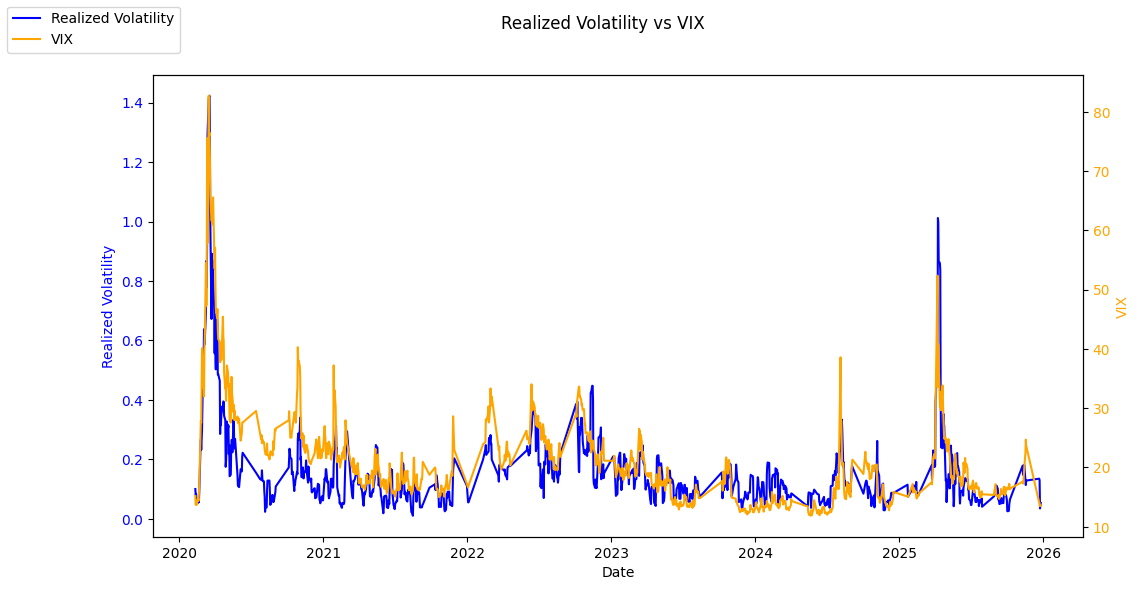

In [16]:
fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.plot(data.index, data["realized_vol5"], label="Realized Volatility", color="blue")
ax1.set_xlabel("Date")
ax1.set_ylabel("Realized Volatility", color="blue")
ax1.tick_params(axis="y", labelcolor="blue")
ax2 = ax1.twinx()
ax2.plot(data.index, data["vix"], label="VIX", color="orange")
ax2.set_ylabel("VIX", color="orange")
ax2.tick_params(axis="y", labelcolor="orange")
fig.suptitle("Realized Volatility vs VIX")
fig.legend(loc="upper left")
plt.show()

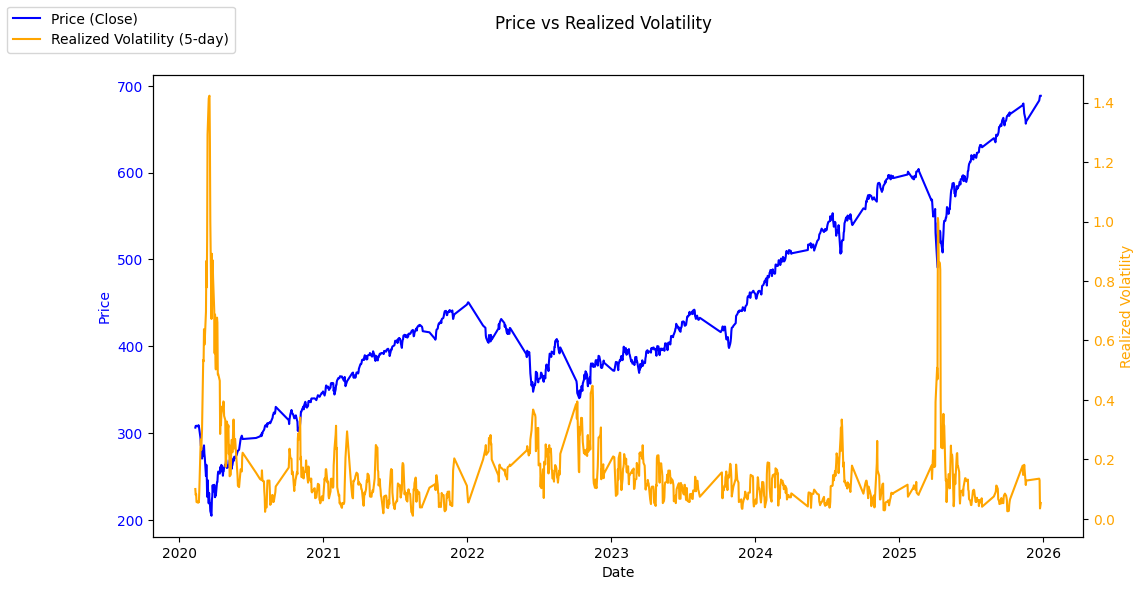

In [17]:
#exploring behaviour of realized volatility time series
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(data.index, data["Close"], label="Price (Close)", color="blue")
ax.set_xlabel("Date")
ax.set_ylabel("Price", color="blue")
ax.tick_params(axis="y", labelcolor="blue")
ax2 = ax.twinx()
ax2.plot(data.index, data["realized_vol5"], label="Realized Volatility (5-day)", color="orange")
ax2.set_ylabel("Realized Volatility", color="orange")
ax2.tick_params(axis="y", labelcolor="orange")
fig.suptitle("Price vs Realized Volatility")
fig.legend(loc="upper left")
plt.show()

In [18]:
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import warnings
warnings.filterwarnings("ignore")

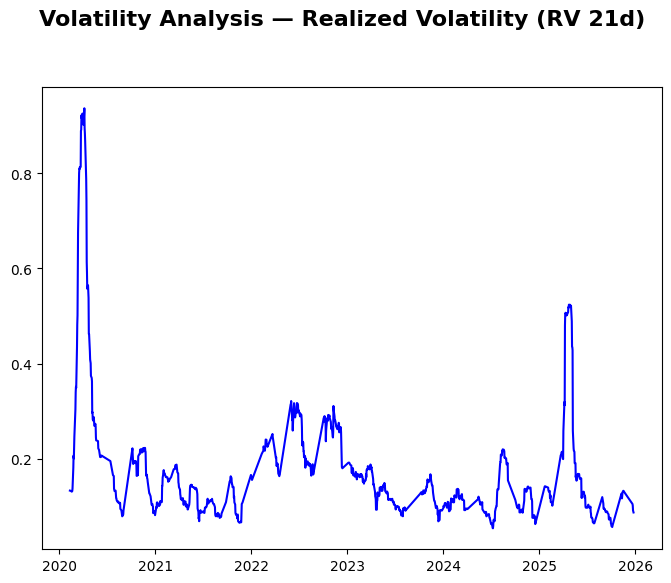

In [24]:
#stationarity test of rv_21d
series = data["realized_vol21"].copy()

fig = plt.figure(figsize=(8, 6))
fig.suptitle("Volatility Analysis — Realized Volatility (RV 21d)",
             fontsize=16, fontweight="bold", y=1.01)
plt.plot(series, label="RV 21d", color="blue")
plt.show()

In [25]:
adf_stat, p_value, _, _, critical_values, _ = adfuller(series.dropna(), autolag="AIC")

In [26]:
p_value

np.float64(6.538786583188465e-06)

with p-value < 0.05, the trend is the realized volatity (21 rolling days) is stationary

In [30]:
#Seasonal Decomposition of RV 21d
stl        = STL(series.dropna(), period=252, seasonal=13, robust=True)
stl_result = stl.fit()

# Strength scores
trend_strength    = max(0, 1 - np.var(stl_result.resid) /
                              np.var(stl_result.trend + stl_result.resid))
seasonal_strength = max(0, 1 - np.var(stl_result.resid) /
                              np.var(stl_result.seasonal + stl_result.resid))

In [32]:
print(f"  Trend Strength    : {trend_strength:.4f}  (>0.6 = strong)")
print(f"  Seasonal Strength : {seasonal_strength:.4f}  (>0.4 = notable)")

  Trend Strength    : 0.0955  (>0.6 = strong)
  Seasonal Strength : 0.1925  (>0.4 = notable)


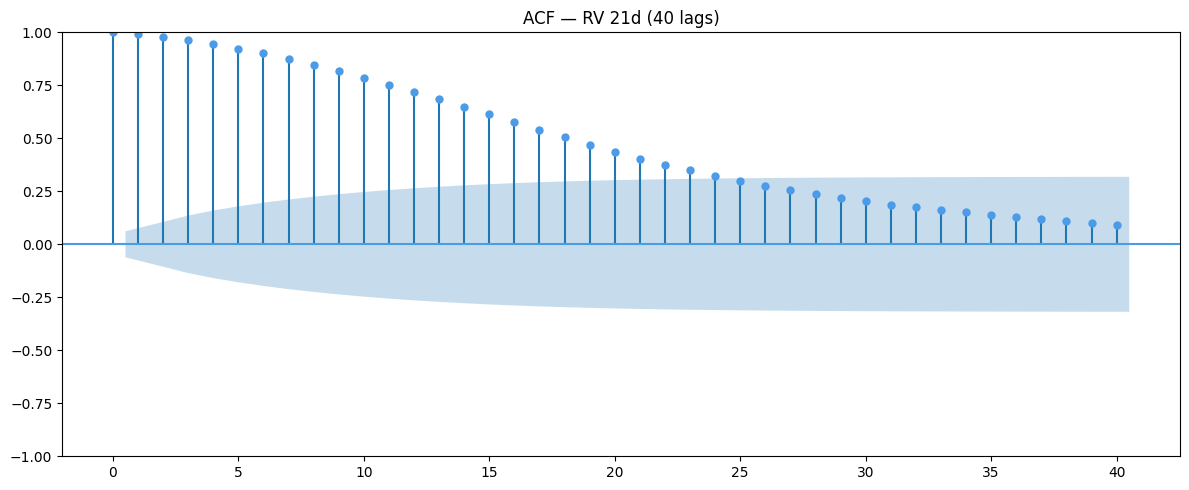

In [ ]:
fig, ax4 = plt.subplots(figsize=(8, 6))
plot_acf( series.dropna(), lags=40, ax=ax4,
          color="#4C9BE8", title="ACF — RV 21d (40 lags)")
plt.tight_layout()
plt.show()

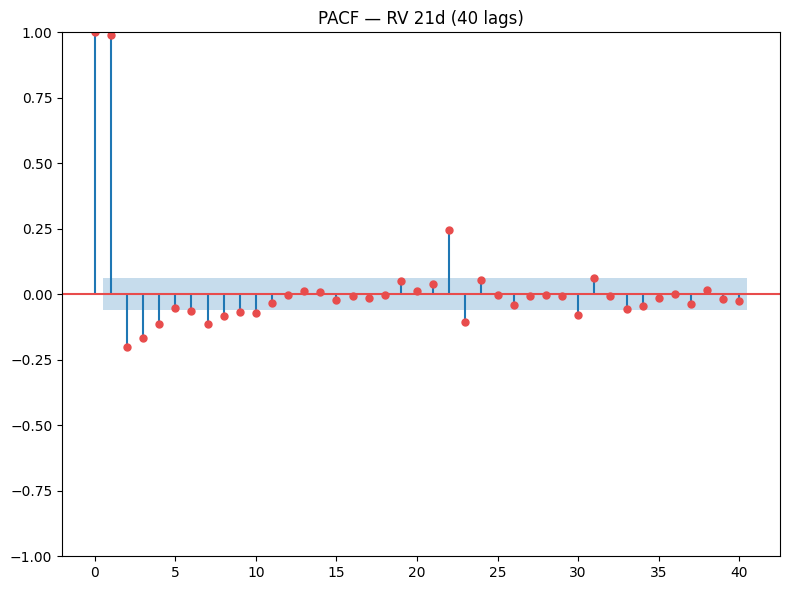

In [35]:
fig, ax5 = plt.subplots(figsize=(8, 6))
plot_pacf(series.dropna(), lags=40, ax=ax5,
          color="#E84C4C", title="PACF — RV 21d (40 lags)")
plt.tight_layout()
plt.show()

In [39]:
data.to_csv("/Users/josephineamponsah/Documents/price_volatility_prediction/data/processed_vol_features.csv")